In [14]:
import tensorflow as tf
from tensorflow import keras

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.applications.xception import preprocess_input # type: ignore

In [16]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    '../data/clothing-dataset-small/train', 
    target_size=(150, 150), 
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [17]:
x, y = next(train_ds)

In [18]:
x.shape

(32, 150, 150, 3)

In [19]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [20]:
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [21]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '../data/clothing-dataset-small/validation', 
    target_size=(150, 150), 
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [22]:
from tensorflow.keras.applications.xception import Xception # type: ignore

In [23]:
base_model = Xception(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

pooling = keras.layers.GlobalAveragePooling2D()
vectors = pooling(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [24]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer, 
    loss=loss, 
    metrics=['accuracy']
)

In [25]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10


/home/nicolas/Machine_Learning_Zoomcamp/venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 574ms/step - accuracy: 0.5787 - loss: 1.5143 - val_accuracy: 0.7419 - val_loss: 1.0741
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 571ms/step - accuracy: 0.8203 - loss: 0.6032 - val_accuracy: 0.7889 - val_loss: 0.9375
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 571ms/step - accuracy: 0.8838 - loss: 0.3570 - val_accuracy: 0.7771 - val_loss: 0.9531
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 61s 636ms/step - accuracy: 0.9126 - loss: 0.2455 - val_accuracy: 0.7771 - val_loss: 0.9707
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 590ms/step - accuracy: 0.9303 - loss: 0.2074 - val_accuracy: 0.7859 - val_loss: 1.1068
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 54s 565ms/step - accuracy: 0.9518 - loss: 0.1379 - val_accuracy: 0.7859 - val_loss: 1.0488
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 569ms/step - accuracy: 0.9688 - loss: 0.0891 - val_accuracy: 0.8152 - val_loss: 0.9992
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 56s 579ms/step - accuracy: 0.9863 - loss: 0.0456 - val_accuracy: 0.797

In [26]:
import matplotlib.pyplot as plt
import numpy as np

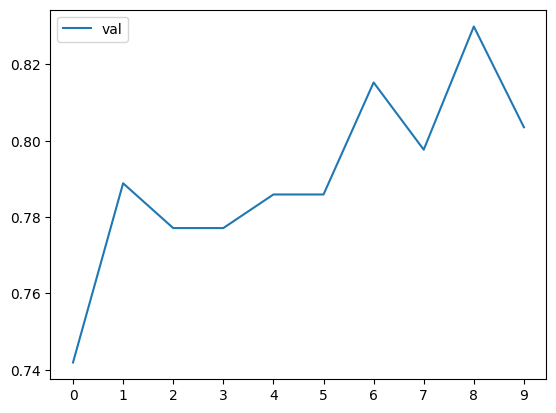

In [27]:
#plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()